# Part 1j: Multi-Modal Data Augmentation

This notebook covers data augmentation for diverse data types:
- Text (NLP)
- Time Series
- Tabular Data
- Speech/Audio
- Document Images

**Author:** Advanced Deep Learning Course Assignment

In [1]:
# Install required packages
!pip install nlpaug -q
!pip install audiomentations -q
!pip install librosa -q
!pip install imbalanced-learn -q

# Download required NLTK data for nlpaug
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("NLTK data downloaded successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 21.0 MB/s eta 0:00:00
NLTK data downloaded successfully!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---
# 1. Text Augmentation with nlpaug

nlpaug provides various text augmentation techniques for NLP tasks.

In [3]:
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.sentence as nas

# Sample text
sample_text = "Machine learning is a subset of artificial intelligence that enables computers to learn from data."
print(f"Original: {sample_text}\n")

Original: Machine learning is a subset of artificial intelligence that enables computers to learn from data.



In [4]:
# 1.1 Synonym Replacement
print("=" * 60)
print("SYNONYM REPLACEMENT")
print("="* 60)

synonym_aug = naw.SynonymAug(aug_src='wordnet')
augmented = synonym_aug.augment(sample_text)
print(f"Original: {sample_text}")
print(f"Augmented: {augmented[0]}")

SYNONYM REPLACEMENT
Original: Machine learning is a subset of artificial intelligence that enables computers to learn from data.
Augmented: Machine encyclopaedism exist a subset of artificial intelligence that enables estimator to learn from data.


In [5]:
# 1.2 Random Word Insertion
print("\n" + "=" * 60)
print("RANDOM WORD INSERTION")
print("=" * 60)

# Note: ContextualWordEmbsAug requires specific transformers version
# Using simpler RandomWordAug instead for compatibility
try:
    insert_aug = naw.ContextualWordEmbsAug(
        model_path='bert-base-uncased',
        action='insert'
    )
    augmented = insert_aug.augment(sample_text)
    print(f"Original: {sample_text}")
    print(f"Augmented: {augmented[0]}")
except Exception as e:
    print(f"ContextualWordEmbsAug not available (transformers compatibility issue)")
    print(f"Using RandomWordAug with 'crop' action as alternative:\n")

    # Alternative: Use TF-IDF based insertion
    try:
        tfidf_aug = naw.TfIdfAug(model_path='.', action='insert')
        augmented = tfidf_aug.augment(sample_text)
        print(f"Original: {sample_text}")
        print(f"TF-IDF Augmented: {augmented[0]}")
    except:
        # Fallback to simple split augmentation
        split_aug = naw.SplitAug()
        augmented = split_aug.augment(sample_text)
        print(f"Original: {sample_text}")
        print(f"Split Augmented: {augmented[0]}")


RANDOM WORD INSERTION


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

ContextualWordEmbsAug not available (transformers compatibility issue)
Using RandomWordAug with 'crop' action as alternative:

Original: Machine learning is a subset of artificial intelligence that enables computers to learn from data.
Split Augmented: Machi ne learn ing is a subset of artificial intellig ence that enab les computers to learn f rom data.


In [6]:
# 1.3 Random Word Deletion
print("\n" + "=" * 60)
print("RANDOM WORD DELETION")
print("=" * 60)

delete_aug = naw.RandomWordAug(action='delete')
for i in range(3):
    augmented = delete_aug.augment(sample_text)
    print(f"Variation {i+1}: {augmented[0]}")


RANDOM WORD DELETION
Variation 1: Learning is subset of artificial intelligence enables to learn from.
Variation 2: Machine learning is a of intelligence computers learn from data.
Variation 3: Machine a of artificial that enables computers to from data.


In [7]:
# 1.4 Random Word Swap
print("\n" + "=" * 60)
print("RANDOM WORD SWAP")
print("=" * 60)

swap_aug = naw.RandomWordAug(action='swap')
for i in range(3):
    augmented = swap_aug.augment(sample_text)
    print(f"Variation {i+1}: {augmented[0]}")


RANDOM WORD SWAP
Variation 1: Learning machine a is subset of artificial intelligence that enables computers to learn data from.
Variation 2: Learning machine a is of subset artificial that intelligence enables to computers learn from data.
Variation 3: Machine learning is a subset artificial of intelligence enables that to computers learn from data.


In [8]:
# 1.5 Character-level augmentation
print("\n" + "=" * 60)
print("CHARACTER-LEVEL AUGMENTATION (Keyboard Typos)")
print("=" * 60)

keyboard_aug = nac.KeyboardAug()
for i in range(3):
    augmented = keyboard_aug.augment(sample_text)
    print(f"Variation {i+1}: {augmented[0]}")


CHARACTER-LEVEL AUGMENTATION (Keyboard Typos)
Variation 1: Machine l4arnijY is a subset of zrtKEicial intelligence gha$ enables computers to learn fr*h vzta.
Variation 2: Mzdhjne :eadninN is a subset of wrtitOcial intelligence tta5 enables coHp6Yers to learn from data.
Variation 3: Machine leaFHinb is a suNseH of artificial &btelKigende that SnaFkes computers to learn from Raya.


In [9]:
# 1.6 Back Translation (requires internet)
print("\n" + "="* 60)
print("BACK TRANSLATION")
print("=" * 60)

try:
    back_translation_aug = naw.BackTranslationAug(
        from_model_name='facebook/wmt19-en-de',
        to_model_name='facebook/wmt19-de-en'
    )
    augmented = back_translation_aug.augment(sample_text)
    print(f"Original: {sample_text}")
    print(f"Back-translated: {augmented[0]}")
except Exception as e:
    print(f"Back translation requires additional setup: {e}")


BACK TRANSLATION


config.json:   0%|          | 0.00/825 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/255 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/235 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

vocab-src.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Back translation requires additional setup: You need to install sacremoses to use XLMTokenizer. See https://pypi.org/project/sacremoses/ for installation.


In [10]:
# Create a text augmentation pipeline
def augment_text_batch(texts, num_augments=3):
    """
    Augment a batch of texts using multiple techniques.
    """
    augmenters = [
        naw.SynonymAug(aug_src='wordnet'),
        naw.RandomWordAug(action='swap'),
        naw.RandomWordAug(action='delete'),
    ]

    augmented_texts = []
    for text in texts:
        augmented_texts.append(text)  # Original
        for aug in augmenters[:num_augments]:
            try:
                aug_text = aug.augment(text)[0]
                augmented_texts.append(aug_text)
            except:
                pass

    return augmented_texts

# Test batch augmentation
sample_texts = [
    "Natural language processing is fascinating.",
    "Deep learning models can understand text."
]

augmented = augment_text_batch(sample_texts)
print("Text Batch Augmentation Results:")
for i, text in enumerate(augmented):
    print(f"{i+1}. {text}")

Text Batch Augmentation Results:
1. Natural language processing is fascinating.
2. Innate language processing personify fascinating.
3. Language natural processing fascinating is.
4. Natural language processing.
5. Deep learning models can understand text.
6. Oceanic abyss learning model can understand textbook.
7. Models deep can learning understand text.
8. Learning can understand.


---
# 2. Time Series Augmentation

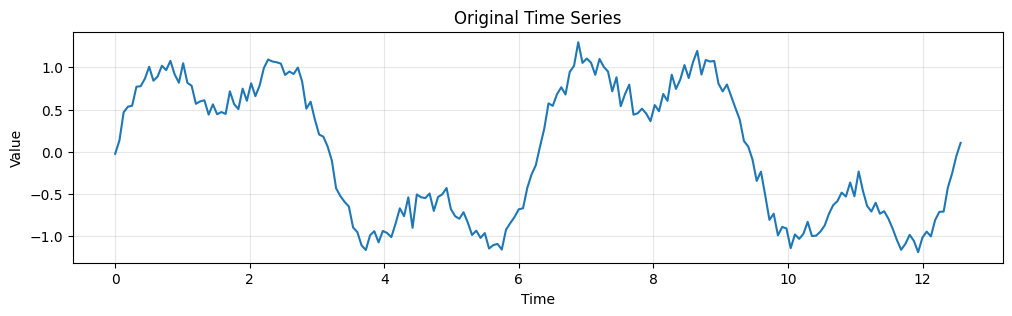

In [11]:
# Generate sample time series data
time = np.linspace(0, 4*np.pi, 200)
original_series = np.sin(time) + 0.5 * np.sin(3*time) + np.random.normal(0, 0.1, 200)

plt.figure(figsize=(12, 3))
plt.plot(time, original_series)
plt.title('Original Time Series')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# Time Series Augmentation Functions

def jittering(series, sigma=0.05):
    """
    Add random noise to the time series.
    """
    noise = np.random.normal(0, sigma, len(series))
    return series + noise

def scaling(series, sigma=0.1):
    """
    Multiply time series by a random factor.
    """
    factor = np.random.normal(1, sigma)
    return series * factor

def time_warping(series, sigma=0.2, knots=4):
    """
    Distort the time axis non-linearly.
    """
    from scipy.interpolate import CubicSpline

    orig_time = np.linspace(0, 1, len(series))
    random_knots = np.random.normal(1, sigma, knots+2)
    random_knots[0] = 1
    random_knots[-1] = 1
    knot_pos = np.linspace(0, 1, knots+2)

    warping_time = np.cumsum(random_knots)
    warping_time = warping_time / warping_time[-1]  # Normalize

    spline = CubicSpline(knot_pos, warping_time)
    warped_time = spline(orig_time)
    warped_time = np.clip(warped_time, 0, 1)

    # Interpolate to get warped series
    warped_indices = (warped_time * (len(series) - 1)).astype(int)
    return series[warped_indices]

def window_slicing(series, reduce_ratio=0.9):
    """
    Extract a random window from the series.
    """
    target_len = int(len(series) * reduce_ratio)
    start = np.random.randint(0, len(series) - target_len)
    return series[start:start + target_len]

def magnitude_warping(series, sigma=0.2, knots=4):
    """
    Multiply time series by a smooth random curve.
    """
    from scipy.interpolate import CubicSpline

    orig_time = np.linspace(0, 1, len(series))
    random_warps = np.random.normal(1, sigma, knots+2)
    knot_pos = np.linspace(0, 1, knots+2)

    spline = CubicSpline(knot_pos, random_warps)
    warp_factors = spline(orig_time)

    return series * warp_factors

def permutation(series, num_segments=4):
    """
    Split series into segments and permute them.
    """
    segment_len = len(series) // num_segments
    segments = [series[i*segment_len:(i+1)*segment_len] for i in range(num_segments)]

    # Handle remainder
    remainder = len(series) % num_segments
    if remainder > 0:
        segments[-1] = np.concatenate([segments[-1], series[-remainder:]])

    np.random.shuffle(segments)
    return np.concatenate(segments)

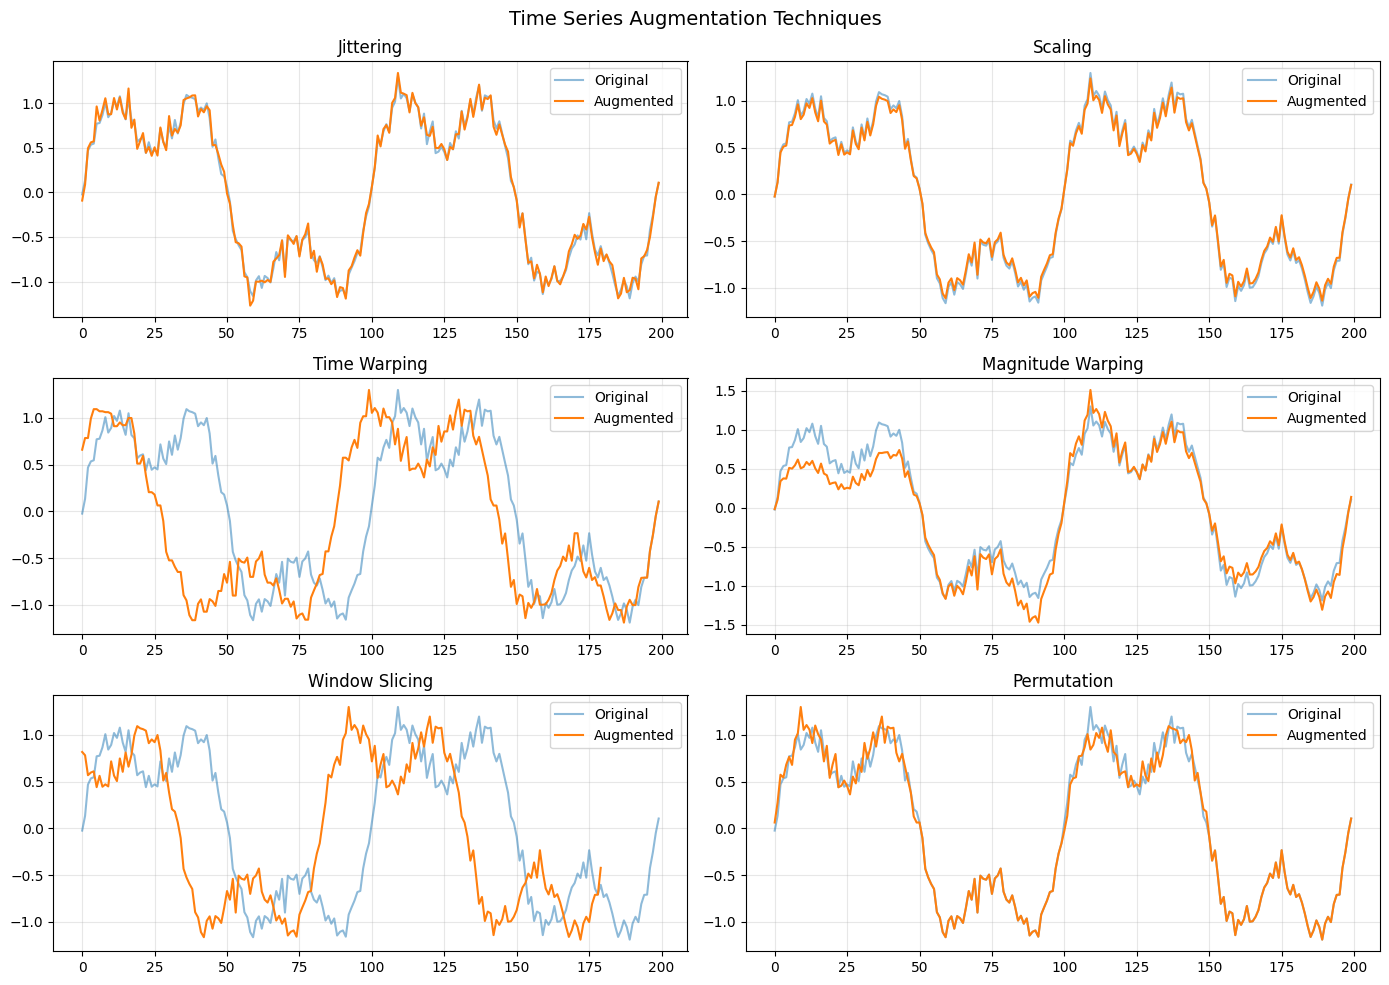

In [13]:
# Visualize all time series augmentations
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Time Series Augmentation Techniques', fontsize=14)

augmentations = [
    ('Jittering', jittering(original_series)),
    ('Scaling', scaling(original_series)),
    ('Time Warping', time_warping(original_series)),
    ('Magnitude Warping', magnitude_warping(original_series)),
    ('Window Slicing', window_slicing(original_series)),
    ('Permutation', permutation(original_series)),
]

for i, (name, aug_series) in enumerate(augmentations):
    row = i // 2
    col = i % 2

    axes[row, col].plot(original_series, alpha=0.5, label='Original')
    axes[row, col].plot(aug_series, label='Augmented')
    axes[row, col].set_title(name)
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# 3. Tabular Data Augmentation

In [14]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Create imbalanced dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    weights=[0.9, 0.1],  # Imbalanced classes
    random_state=42
)

print("Original class distribution:")
print(pd.Series(y).value_counts())

Original class distribution:
0    896
1    104
Name: count, dtype: int64


In [15]:
# 3.1 SMOTE (Synthetic Minority Over-sampling Technique)
print("\n" + "=" * 60)
print("SMOTE - Synthetic Minority Over-sampling")
print("=" * 60)

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print(f"Original: {len(y)} samples")
print(f"After SMOTE: {len(y_smote)} samples")
print(f"Class distribution: {pd.Series(y_smote).value_counts().to_dict()}")


SMOTE - Synthetic Minority Over-sampling
Original: 1000 samples
After SMOTE: 1792 samples
Class distribution: {0: 896, 1: 896}


In [16]:
# 3.2 ADASYN (Adaptive Synthetic Sampling)
print("\n" + "=" * 60)
print("ADASYN - Adaptive Synthetic Sampling")
print("=" * 60)

adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X, y)

print(f"Original: {len(y)} samples")
print(f"After ADASYN: {len(y_adasyn)} samples")
print(f"Class distribution: {pd.Series(y_adasyn).value_counts().to_dict()}")


ADASYN - Adaptive Synthetic Sampling
Original: 1000 samples
After ADASYN: 1774 samples
Class distribution: {0: 896, 1: 878}


In [17]:
# Custom tabular augmentation functions

def add_gaussian_noise(df, columns, noise_level=0.1):
    """
    Add Gaussian noise to numeric columns.
    """
    df_aug = df.copy()
    for col in columns:
        std = df[col].std()
        noise = np.random.normal(0, std * noise_level, len(df))
        df_aug[col] = df[col] + noise
    return df_aug

def random_feature_permutation(df, columns):
    """
    Randomly permute values within each column.
    """
    df_aug = df.copy()
    for col in columns:
        df_aug[col] = np.random.permutation(df[col].values)
    return df_aug

def mixup_tabular(X, y, alpha=0.2):
    """
    MixUp augmentation for tabular data.
    """
    n = len(X)
    indices = np.random.permutation(n)

    lam = np.random.beta(alpha, alpha, n)
    lam = lam.reshape(-1, 1)

    X_mixed = lam * X + (1 - lam) * X[indices]
    y_mixed = lam.squeeze() * y + (1 - lam.squeeze()) * y[indices]

    return X_mixed, y_mixed

# Test MixUp
X_mixup, y_mixup = mixup_tabular(X, y)
print(f"\nMixUp: Created {len(X_mixup)} mixed samples")


MixUp: Created 1000 mixed samples


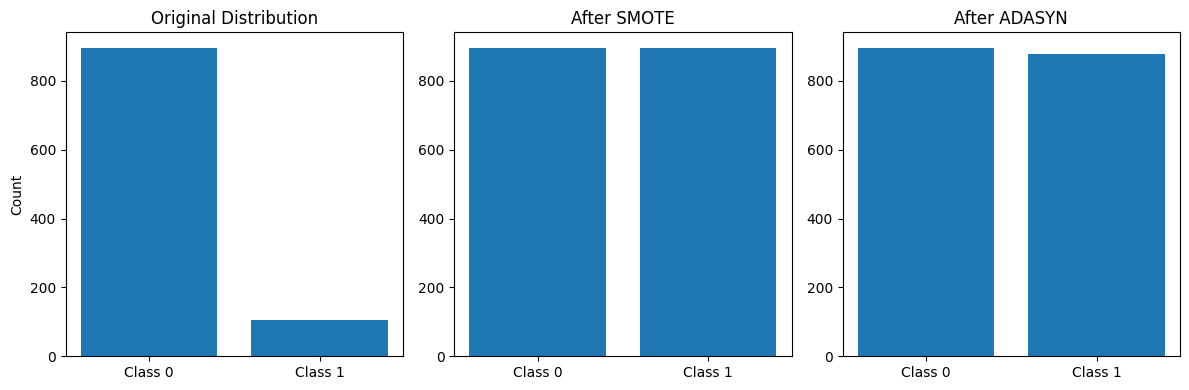

In [18]:
# Visualize class distributions
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original
axes[0].bar(['Class 0', 'Class 1'], [sum(y==0), sum(y==1)])
axes[0].set_title('Original Distribution')
axes[0].set_ylabel('Count')

# SMOTE
axes[1].bar(['Class 0', 'Class 1'], [sum(y_smote==0), sum(y_smote==1)])
axes[1].set_title('After SMOTE')

# ADASYN
axes[2].bar(['Class 0', 'Class 1'], [sum(y_adasyn==0), sum(y_adasyn==1)])
axes[2].set_title('After ADASYN')

plt.tight_layout()
plt.show()

---
# 4. Speech/Audio Augmentation

In [19]:
import librosa
import librosa.display

# Generate sample audio signal (sine wave with harmonics)
sr = 22050  # Sample rate
duration = 2  # seconds
t = np.linspace(0, duration, sr * duration)

# Create a complex audio signal
freq = 440  # A4 note
audio = np.sin(2 * np.pi * freq * t) + 0.5 * np.sin(2 * np.pi * 2 * freq * t)
audio = audio / np.max(np.abs(audio))  # Normalize

print(f"Generated audio: {duration}s at {sr}Hz")

Generated audio: 2s at 22050Hz


In [20]:
# Audio augmentation functions

def add_noise(audio, noise_factor=0.005):
    """Add random noise to audio."""
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

def time_stretch(audio, rate=1.0):
    """Stretch/compress audio in time domain."""
    return librosa.effects.time_stretch(audio, rate=rate)

def pitch_shift(audio, sr, n_steps=0):
    """Shift pitch by n semitones."""
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

def random_gain(audio, min_gain=0.8, max_gain=1.2):
    """Apply random gain/volume change."""
    gain = np.random.uniform(min_gain, max_gain)
    return audio * gain

def time_shift(audio, shift_max=0.2):
    """Shift audio in time."""
    shift = int(len(audio) * np.random.uniform(-shift_max, shift_max))
    return np.roll(audio, shift)

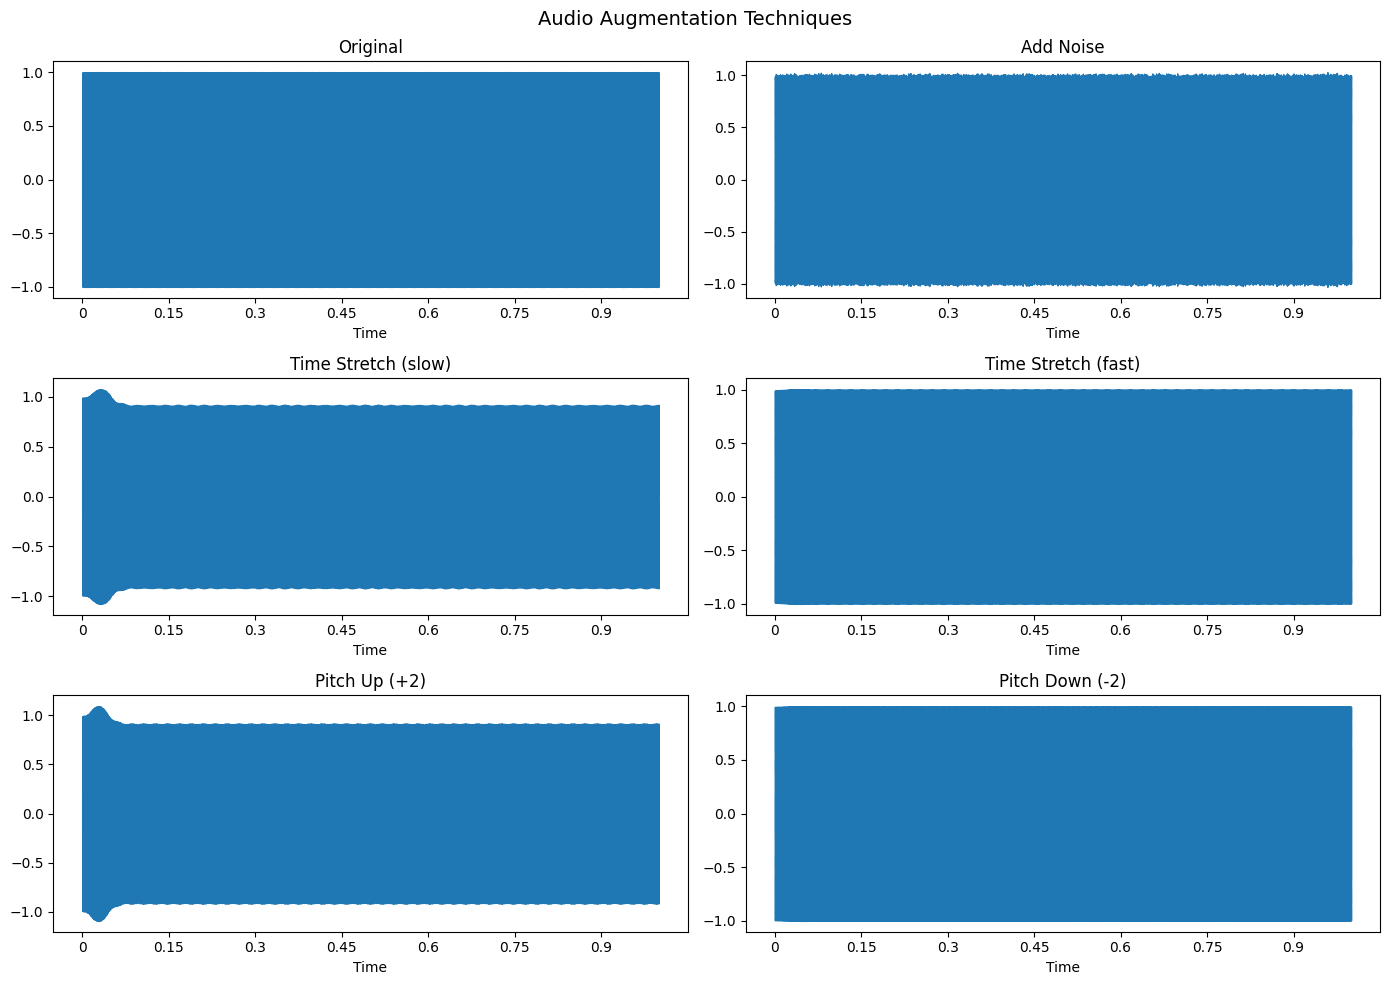

In [21]:
# Apply augmentations
audio_augs = [
    ('Original', audio),
    ('Add Noise', add_noise(audio, 0.01)),
    ('Time Stretch (slow)', time_stretch(audio, 0.8)),
    ('Time Stretch (fast)', time_stretch(audio, 1.2)),
    ('Pitch Up (+2)', pitch_shift(audio, sr, 2)),
    ('Pitch Down (-2)', pitch_shift(audio, sr, -2)),
]

# Visualize
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Audio Augmentation Techniques', fontsize=14)

for i, (name, aug_audio) in enumerate(audio_augs):
    row = i // 2
    col = i % 2

    # Plot waveform
    librosa.display.waveshow(aug_audio[:sr], sr=sr, ax=axes[row, col])
    axes[row, col].set_title(name)

plt.tight_layout()
plt.show()

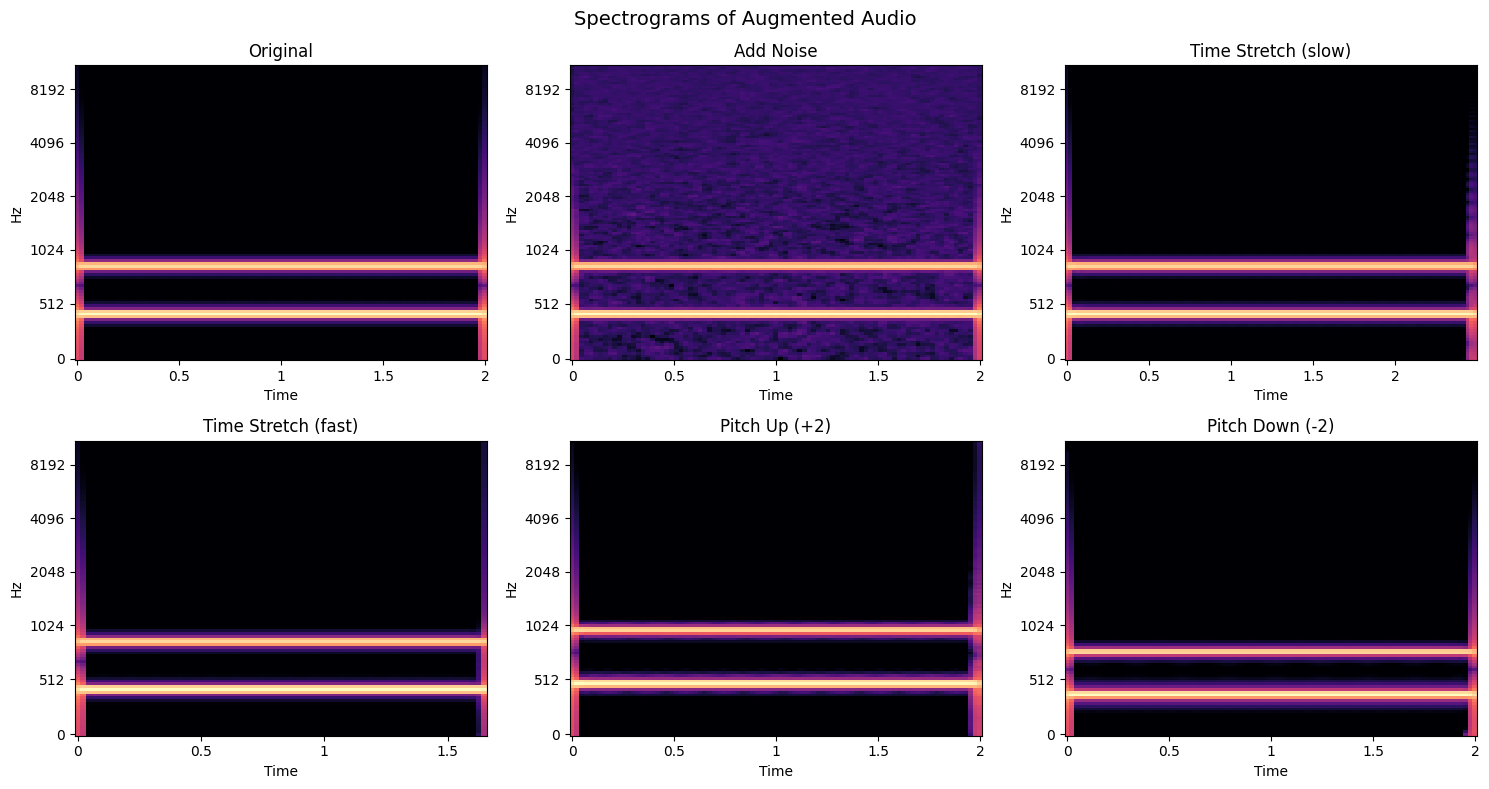

In [22]:
# Visualize spectrograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Spectrograms of Augmented Audio', fontsize=14)

for i, (name, aug_audio) in enumerate(audio_augs):
    row = i // 3
    col = i % 3

    # Compute mel spectrogram
    S = librosa.feature.melspectrogram(y=aug_audio, sr=sr)
    S_db = librosa.power_to_db(S, ref=np.max)

    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[row, col])
    axes[row, col].set_title(name)

plt.tight_layout()
plt.show()

---
# 5. Document Image Augmentation

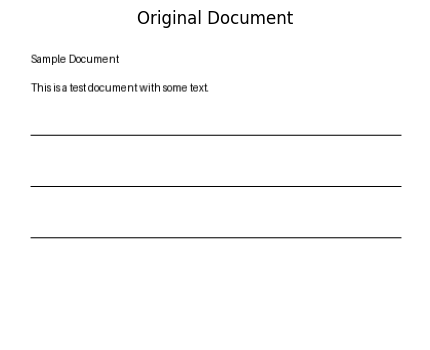

In [23]:
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import cv2

# Create a sample document image
def create_document_image(text="Sample Document\n\nThis is a test document with some text."):
    """Create a simple document image."""
    img = Image.new('RGB', (400, 300), color='white')
    draw = ImageDraw.Draw(img)

    # Add text
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 20)
    except:
        font = ImageFont.load_default()

    draw.text((20, 20), text, fill='black', font=font)

    # Add some lines (like a form)
    draw.line([(20, 100), (380, 100)], fill='black', width=1)
    draw.line([(20, 150), (380, 150)], fill='black', width=1)
    draw.line([(20, 200), (380, 200)], fill='black', width=1)

    return img

doc_image = create_document_image()
plt.figure(figsize=(6, 4))
plt.imshow(doc_image)
plt.title('Original Document')
plt.axis('off')
plt.show()

In [24]:
# Document-specific augmentation functions

def add_document_shadow(img, shadow_intensity=0.3):
    """Add shadow effect (like photography of documents)."""
    img_array = np.array(img).astype(float)
    h, w = img_array.shape[:2]

    # Create gradient shadow
    x = np.linspace(0, 1, w)
    y = np.linspace(0, 1, h)
    xx, yy = np.meshgrid(x, y)
    shadow = 1 - shadow_intensity * (xx * 0.5 + yy * 0.5)

    # Apply shadow
    img_array = img_array * shadow[:, :, np.newaxis]
    return Image.fromarray(img_array.astype(np.uint8))

def add_paper_texture(img, noise_level=10):
    """Add paper-like texture."""
    img_array = np.array(img).astype(float)
    noise = np.random.randint(-noise_level, noise_level, img_array.shape)
    img_array = np.clip(img_array + noise, 0, 255)
    return Image.fromarray(img_array.astype(np.uint8))

def simulate_scanning(img, blur_radius=1, quality=90):
    """Simulate scanning artifacts."""
    # Slight blur
    img = img.filter(ImageFilter.GaussianBlur(blur_radius))

    # JPEG compression
    from io import BytesIO
    buffer = BytesIO()
    img.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)
    return Image.open(buffer)

def add_perspective_warp(img, intensity=0.02):
    """Add perspective distortion (like photographed document)."""
    img_array = np.array(img)
    h, w = img_array.shape[:2]

    # Define source points (corners)
    src_pts = np.float32([[0, 0], [w, 0], [0, h], [w, h]])

    # Add random perturbation
    dst_pts = src_pts + np.random.uniform(-w*intensity, w*intensity, src_pts.shape).astype(np.float32)

    # Compute transform
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(img_array, M, (w, h),
                                  borderMode=cv2.BORDER_CONSTANT,
                                  borderValue=(255, 255, 255))

    return Image.fromarray(warped)

def add_ink_bleed(img, kernel_size=3):
    """Simulate ink bleeding/spreading."""
    img_array = np.array(img)

    # Dilate dark areas
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    dilated = cv2.dilate(255 - gray, kernel, iterations=1)

    # Blend back
    result = img_array.copy()
    mask = dilated > 128
    result[mask] = result[mask] * 0.8  # Darken bleeding areas

    return Image.fromarray(result)

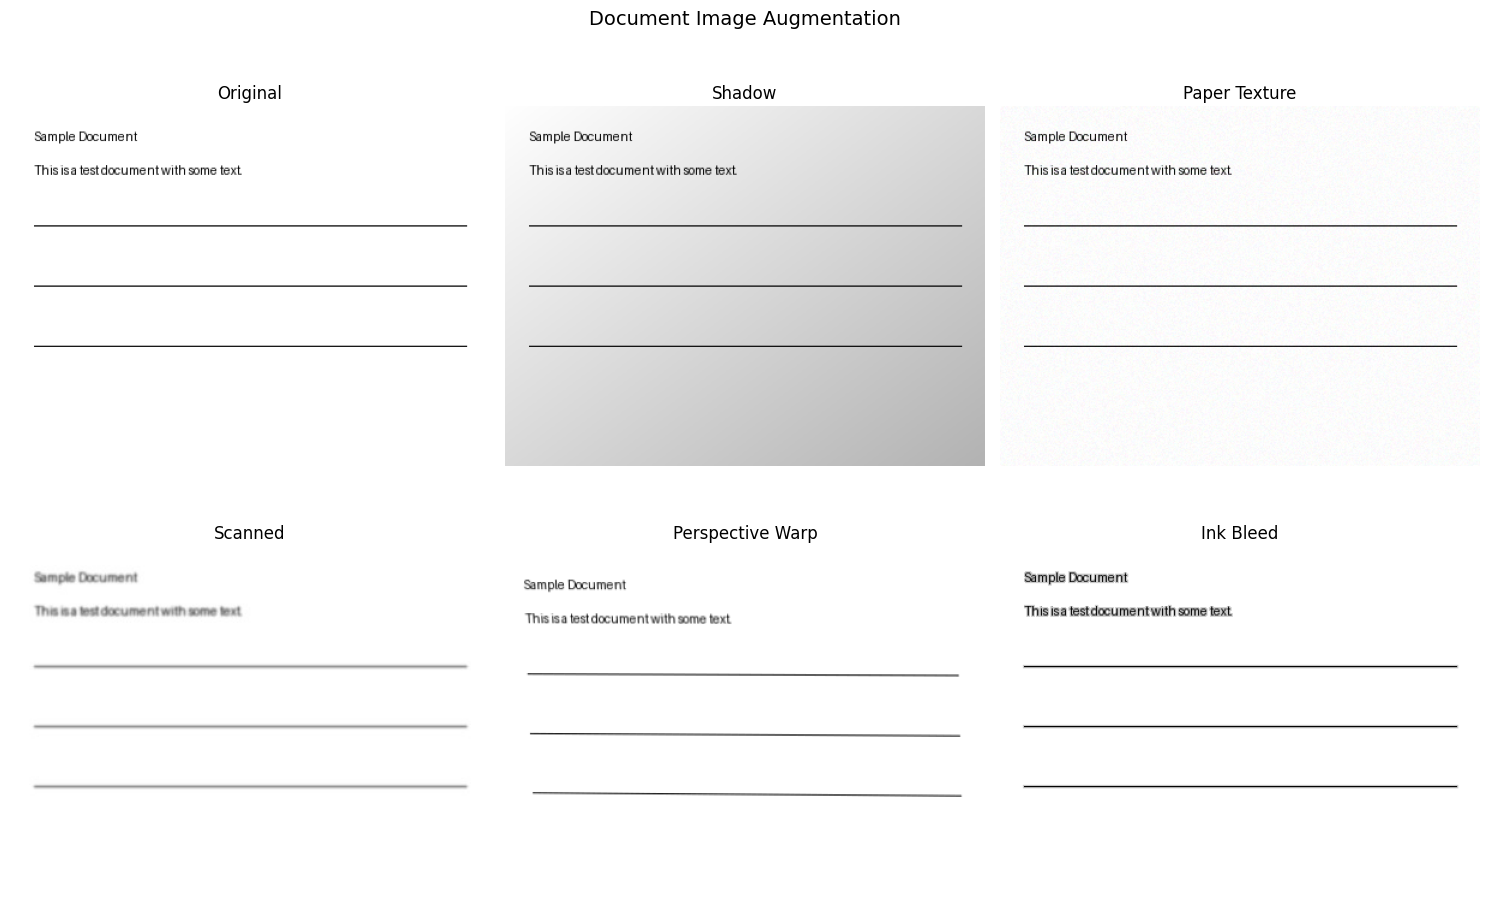

In [25]:
# Visualize document augmentations
doc_augs = [
    ('Original', doc_image),
    ('Shadow', add_document_shadow(doc_image)),
    ('Paper Texture', add_paper_texture(doc_image)),
    ('Scanned', simulate_scanning(doc_image)),
    ('Perspective Warp', add_perspective_warp(doc_image)),
    ('Ink Bleed', add_ink_bleed(doc_image)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Document Image Augmentation', fontsize=14)

for i, (name, aug_img) in enumerate(doc_augs):
    row = i // 3
    col = i % 3
    axes[row, col].imshow(aug_img)
    axes[row, col].set_title(name)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

---
## Summary

### Text Augmentation (nlpaug):

| Technique | Description |
|-----------|-------------|
| Synonym Replacement | Replace words with synonyms |
| Random Insertion | Insert related words |
| Random Deletion | Remove random words |
| Random Swap | Swap adjacent words |
| Back Translation | Translate to another language and back |

### Time Series Augmentation:

| Technique | Description |
|-----------|-------------|
| Jittering | Add random noise |
| Scaling | Multiply by random factor |
| Time Warping | Non-linear time distortion |
| Window Slicing | Extract random windows |
| Permutation | Shuffle segments |

### Tabular Data Augmentation:

| Technique | Description |
|-----------|-------------|
| SMOTE | Synthetic minority oversampling |
| ADASYN | Adaptive synthetic sampling |
| Noise Injection | Add Gaussian noise |
| MixUp | Blend samples |

### Audio Augmentation:

| Technique | Description |
|-----------|-------------|
| Add Noise | Random noise injection |
| Time Stretch | Speed up/slow down |
| Pitch Shift | Change pitch |
| Time Shift | Shift in time domain |

### Document Image Augmentation:

| Technique | Description |
|-----------|-------------|
| Shadow | Add lighting shadows |
| Paper Texture | Add paper-like noise |
| Perspective | Simulate camera angle |
| Scan Simulation | JPEG artifacts, blur |